# Embedding filters 4 — Ensemble Kalman & information filters

Two ways to carry a *full* covariance on a high-dimensional embedding
without the `O(D^2)`-`O(D^3)` cost of a dense Kalman filter:

- **Information filter** — the exact Kalman dual. It stores the
  *inverse* covariance, which turns the measurement update into a
  plain addition. Its posterior is identical to the Kalman filter's
  (the library test asserts this to 1e-4).
- **Ensemble Kalman filter (EnKF)** — represents the covariance
  *implicitly* by an ensemble of sample states. Cost scales with the
  ensemble size, not `D`-squared; this is the method built for very
  high-dimensional filtering. unitrack uses a deterministic ETKF
  transform, so the step is reproducible.


In [1]:
import torch
import matplotlib.pyplot as plt

import unitrack
from unitrack.assignment import Associate, Jonker
from unitrack.costs import Cosine
from unitrack.data import Detections, FrameContext, TensorSpec
from unitrack.lifecycle import IncludeAll, NoLifecycle
from unitrack.pipeline import Pipe

torch.manual_seed(0)

D = 16          # embedding dimensionality (256+ in practice; 16 plots fast)
T = 44          # frames

def make_clip(noise=0.15, seed=0, switch=None):
    """
    A unit embedding that rotates slowly in the (e0, e1) plane plus
    per-frame noise in all D dims. Rotating in a known plane means
    projecting onto dims (0, 1) shows the true path as a circle arc.
    `switch` optionally rotates the plane mid-clip (an appearance change).
    """
    g = torch.Generator().manual_seed(seed)
    t = torch.arange(T).float()
    theta = 0.10 * t
    truth = torch.zeros(T, D)
    truth[:, 0] = torch.cos(theta)
    truth[:, 1] = torch.sin(theta)
    if switch is not None:
        # after `switch`, swap appearance into the (e2, e3) plane.
        truth[switch:, :] = 0.0
        truth[switch:, 2] = torch.cos(theta[switch:])
        truth[switch:, 3] = torch.sin(theta[switch:])
    obs = truth + noise * torch.randn(T, D, generator=g)
    obs = torch.nn.functional.normalize(obs, dim=-1)
    dets = [Detections(index=torch.tensor([0]), emb=obs[k:k + 1].clone(),
                       batch_size=[1]) for k in range(T)]
    return t, truth, obs, dets

def run(tracker, dets, fields=("emb",)):
    """Run a single-object clip through a real Tracker; collect snapshot fields."""
    ms = unitrack.MultiStream(tracker)
    rec = {f: [] for f in fields}
    for k, d in enumerate(dets):
        ctx = FrameContext.make(frame_idx=k, delta=1.0, fps=1.0, stream_key=0)
        res = ms.step(stream_key=0, detections=d, ctx=ctx)
        for f in fields:
            rec[f].append(getattr(res.snapshot, f)[0].clone())
    return {f: torch.stack(v) for f, v in rec.items()}

def cos_to_truth(est, truth):
    e = torch.nn.functional.normalize(est, dim=-1)
    u = torch.nn.functional.normalize(truth, dim=-1)
    return (e * u).sum(-1)

t, truth, obs, dets = make_clip()
print(f"clip: {T} frames, D={D}; raw-detection mean cosine-to-truth "
      f"= {cos_to_truth(obs, truth).mean():.3f}")


clip: 44 frames, D=16; raw-detection mean cosine-to-truth = 0.855


In [2]:
from unitrack.states import enkf_state_entries, information_state_entries

def tracker_for(states):
    return unitrack.Tracker(
        root=Pipe(cost=Cosine("emb"), assoc=Associate(Jonker(threshold=0.6))),
        states=states, lifecycle=NoLifecycle(), visibility=IncludeAll(),
    )

info = run(tracker_for(information_state_entries("emb", dim=D, q=0.02, r=0.2)),
           dets, fields=("emb", "emb_infomat"))
enkf = run(tracker_for(enkf_state_entries("emb", dim=D, ensemble_size=24,
                                          q=0.02, r=0.2, init_std=0.4)),
           dets, fields=("emb", "emb_ensemble"))


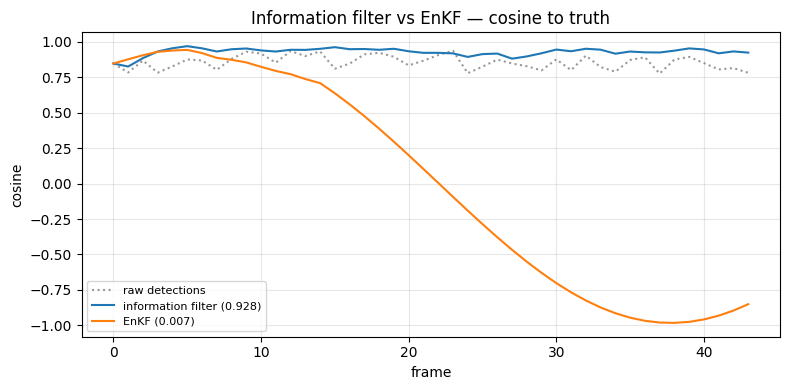

In [3]:
# Both track the drift; compare to raw.
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t, cos_to_truth(obs, truth), color="0.6", ls=":", label="raw detections")
ax.plot(t, cos_to_truth(info["emb"], truth), color="tab:blue",
        label=f"information filter ({cos_to_truth(info['emb'], truth).mean():.3f})")
ax.plot(t, cos_to_truth(enkf["emb"], truth), color="tab:orange",
        label=f"EnKF ({cos_to_truth(enkf['emb'], truth).mean():.3f})")
ax.set_title("Information filter vs EnKF — cosine to truth")
ax.set_xlabel("frame"); ax.set_ylabel("cosine"); ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Two views of the same shrinking uncertainty

Left: the EnKF ensemble, projected to 2-D — the cloud of members
contracts as measurements arrive (that contraction *is* the
covariance update; no `D`-by-`D` matrix is ever formed). Right: the
information filter's covariance trace (`tr(Y^{-1})`) falling in
lockstep — the explicit dual of the same belief.


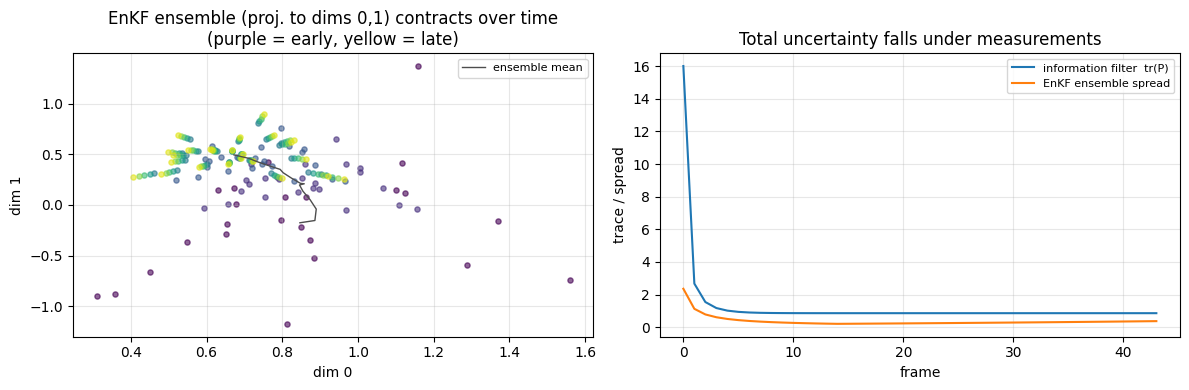

In [4]:
fig, (axe, axt) = plt.subplots(1, 2, figsize=(12, 4))
cmap = plt.get_cmap("viridis")
for k in range(0, T, 6):
    members = enkf["emb_ensemble"][k]  # (E, D)
    axe.scatter(members[:, 0], members[:, 1], s=14, color=cmap(k / T),
                alpha=0.6)
axe.plot(enkf["emb"][:, 0], enkf["emb"][:, 1], "-", color="0.3", lw=1,
         label="ensemble mean")
axe.set_title("EnKF ensemble (proj. to dims 0,1) contracts over time\n"
              "(purple = early, yellow = late)")
axe.set_xlabel("dim 0"); axe.set_ylabel("dim 1"); axe.legend(fontsize=8)
axe.grid(alpha=0.3)

cov_trace = torch.stack([
    torch.linalg.inv(info["emb_infomat"][k]).diagonal().sum() for k in range(T)])
ens_trace = torch.stack([enkf["emb_ensemble"][k].var(dim=0).sum() for k in range(T)])
axt.plot(t, cov_trace, color="tab:blue", label="information filter  tr(P)")
axt.plot(t, ens_trace, color="tab:orange", label="EnKF ensemble spread")
axt.set_title("Total uncertainty falls under measurements")
axt.set_xlabel("frame"); axt.set_ylabel("trace / spread"); axt.legend(fontsize=8)
axt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**Takeaway.** Use the **information filter** when you want the exact
Gaussian posterior and `D` is moderate (its update is a cheap
addition, ideal for fusing many cues). Use the **EnKF** when `D` is
large enough that a dense covariance is impractical — the ensemble
buys you covariance information at a cost set by the ensemble size.
